In [1]:

import model as mm
from sklearn.pipeline import Pipeline
import pandas as pd
from sqlalchemy import create_engine
import tools.helpers as hh
import tools.helper_functions_visualizer as hv
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from venn import venn
from pathlib import Path

matplotlib-venn is already installed.
imports successfully completed


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
# !pip install imblearn


In [4]:
import importlib
importlib.reload(hv)

matplotlib-venn is already installed.
imports successfully completed


<module 'tools.helper_functions_visualizer' from '/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building/tools/helper_functions_visualizer.py'>

In [5]:
pd.set_option('display.max_columns', None)


In [6]:
DATA_ROOT = Path("/Users/gnaanikko.pa/Documents/Academic /MIMIC/model_building")
PARQ_DIR = DATA_ROOT / "parq"

In [7]:

df_resp_inf_icu_final = pd.read_parquet(PARQ_DIR / "df_resp_inf_icu_final.parq")


In [8]:
hh.dxx(df_resp_inf_icu_final)

11.9k Unique Patient IDs (11905)
13.6k Unique Admission IDs (13611)
16.4k Unique ICU Stay IDs (16438)
18.1k Rows, shape: (18109, 6)



,subject_id,hadm_id,stay_id,seq_num,icd_version,icd_code
dtype,int64,int64,int64,int64,int64,object
NotNA | NA,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0,18109 | 0
nunique,11905,13611,16438,38,2,142
0,10001843,26133978,39698942,4,10,J189
1,10001884,26184834,37510196,19,10,J0190
2,10002155,20345487,32358465,2,9,486


In [9]:
# feature_df=hh.load_data('./parq/feature_df1_17Feb26_1830.parquet')
feature_df= hh.load_data('./parq/feature_df_selected_df_03Mar26_2006.parquet')


In [59]:
feature_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'diastolic_bp', 'heart_rate',
       'mean_arterial_pressure', 'respiratory_rate', 'spo2', 'systolic_bp',
       'temperature_c', 'Alanine Aminotransferase (ALT)',
       'Alkaline Phosphatase', 'Anion Gap', 'Asparate Aminotransferase (AST)',
       'Base Excess', 'Bicarbonate', 'Bilirubin, Total', 'Calcium, Total',
       'Calculated Total CO2', 'Chloride', 'Creatinine', 'Glucose',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lactate', 'MCH', 'MCHC', 'MCV',
       'Magnesium', 'PT', 'PTT', 'Phosphate', 'Platelet Count', 'Potassium',
       'RDW', 'Red Blood Cells', 'Sodium', 'Urea Nitrogen',
       'White Blood Cells', 'pCO2', 'pH', 'pO2', 'gender', 'age_at_admission',
       'insurance', 'race', 'marital_status', 'language', 'admission_type',
       'admission_location', 'prior_ab_count', 'Acinetobacter',
       'AmpC_Producers', 'Carbopenam Resistant Enterobacterales',
       'ESBL_Enterobacterales', 'Enterococcus_VRE', 'Enterococcus_VSE'

In [10]:
all_ast_final_df=hh.load_data('./parq/all_ast_final_df_06Mar26_2018.parquet')

In [11]:
all_ast_final_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'microevent_id', 'chartdate', 'charttime',
       'spec_type_desc', 'storetime', 'test_name', 'org_name', 'ab_name',
       'interpretation', 'dilution_value', 'comments', 'combined_col',
       'AST_PATTERN', 'mapped_letter', 'final_class', 'binary_result',
       'therapy_group'],
      dtype='object')

In [12]:
all_ast_final_df.ab_name.unique()

array(['ERYTHROMYCIN', 'NITROFURANTOIN', 'TETRACYCLINE', 'GENTAMICIN',
       'VANCOMYCIN', 'OXACILLIN', 'LEVOFLOXACIN', 'CLINDAMYCIN',
       'TRIMETHOPRIM/SULFA', 'RIFAMPIN', 'TOBRAMYCIN', 'CEFTAZIDIME',
       'CEFTRIAXONE', 'CIPROFLOXACIN', 'PIPERACILLIN/TAZO', 'CEFEPIME',
       'MEROPENEM', 'AMPICILLIN', 'CEFAZOLIN', 'AMPICILLIN/SULBACTAM',
       'PENICILLIN G', 'LINEZOLID', 'AMIKACIN', 'DAPTOMYCIN', 'AZTREONAM',
       'CEFIDEROCOL', 'CEFTAZIDIME/AVIBACTAM', 'IMIPENEM/RELEBACTAM',
       'MEROPENEM/VABORBACTAM', 'CEFUROXIME', 'PIPERACILLIN', 'IMIPENEM',
       'FLUCONAZOLE', 'MINOCYCLINE', 'FOSFOMYCIN', 'ERTAPENEM',
       'CEFTOLOZANE/TAZOBACTAM', 'DOXYCYCLINE', 'CEFTAROLINE',
       'CASPOFUNGIN', 'ERAVACYCLINE', 'OMADACYCLINE', 'TIGECYCLINE',
       'MICAFUNGIN', 'VORICONZAOLE', 'COLISTIN', 'CHLORAMPHENICOL'],
      dtype=object)

In [13]:
abx_group = {

"VANCOMYCIN":"MRSA",
"LINEZOLID":"MRSA",
"DAPTOMYCIN":"MRSA",
"CEFTAROLINE":"MRSA",
"RIFAMPIN":"MRSA",
"CLINDAMYCIN":"MRSA",

"ERYTHROMYCIN":"Other_Gram_Positive",
"PENICILLIN G":"Other_Gram_Positive",
"AMPICILLIN":"Other_Gram_Positive",
"CEFAZOLIN":"Other_Gram_Positive",
"TETRACYCLINE":"Other_Gram_Positive",
"DOXYCYCLINE":"Other_Gram_Positive",
"MINOCYCLINE":"Other_Gram_Positive",
"CHLORAMPHENICOL":"Other_Gram_Positive",
"TRIMETHOPRIM/SULFA":"Other_Gram_Positive",

"CEFTRIAXONE":"Standard_GNB",
"CEFUROXIME":"Standard_GNB",
"AMPICILLIN/SULBACTAM":"Standard_GNB",
"GENTAMICIN":"Standard_GNB",
"LEVOFLOXACIN":"Standard_GNB",
"CIPROFLOXACIN":"Standard_GNB",
"AZTREONAM":"Standard_GNB",
"PIPERACILLIN":"Standard_GNB",
"FOSFOMYCIN":"Standard_GNB",
"NITROFURANTOIN":"Standard_GNB",

"MEROPENEM":"ESBL_Enterobacterales",
"IMIPENEM":"ESBL_Enterobacterales",
"ERTAPENEM":"ESBL_Enterobacterales",

"PIPERACILLIN/TAZO":"Pseudomonas",
"CEFEPIME":"Pseudomonas",
"CEFTAZIDIME":"Pseudomonas",
"CEFTOLOZANE/TAZOBACTAM":"Pseudomonas",

"COLISTIN":"MDR_GNB",
"TIGECYCLINE":"MDR_GNB",
"ERAVACYCLINE":"MDR_GNB",
"OMADACYCLINE":"MDR_GNB",
"CEFIDEROCOL":"MDR_GNB",
"CEFTAZIDIME/AVIBACTAM":"MDR_GNB",
"MEROPENEM/VABORBACTAM":"MDR_GNB",
"IMIPENEM/RELEBACTAM":"MDR_GNB"
}

In [14]:
all_ast_final_df["abx_group"] = all_ast_final_df["ab_name"].map(abx_group)

In [15]:
time_df=hh.load_data('./parq/time_df05Mar26_2130.parquet')


In [16]:
resp_ast_final_df= hh.df_subset(all_ast_final_df,time_df,by_col='hadm_id')

#### check

In [17]:
counts = (
    resp_ast_final_df
    .groupby(['hadm_id','interpretation',])
    .size()
    .unstack(fill_value=0)
)

In [18]:
counts['total'] = counts.sum(axis=1)

In [19]:
counts['S_pct'] = counts['S'] / counts['total']
counts['R_pct'] = counts['R'] / counts['total']

In [20]:
counts['group'] = counts.apply(
    lambda x: 'S' if x['S_pct'] > 0.50 else 'R',
    axis=1
)

In [21]:
final_df = counts.reset_index()[[
    'hadm_id','S_pct','R_pct','group'
]]

In [22]:
final_df.group.value_counts()

group
S    3583
R     843
Name: count, dtype: int64

In [23]:
final_counts_df= final_df.merge(all_ast_final_df,on=[ 'hadm_id'],how='left')


In [24]:
final_counts_df.columns

Index(['hadm_id', 'S_pct', 'R_pct', 'group', 'subject_id', 'stay_id',
       'first_careunit', 'last_careunit', 'intime', 'outtime', 'los',
       'microevent_id', 'chartdate', 'charttime', 'spec_type_desc',
       'storetime', 'test_name', 'org_name', 'ab_name', 'interpretation',
       'dilution_value', 'comments', 'combined_col', 'AST_PATTERN',
       'mapped_letter', 'final_class', 'binary_result', 'therapy_group',
       'abx_group'],
      dtype='object')

In [25]:
final_counts_dff=final_counts_df[[ 'subject_id', 'hadm_id','stay_id',
       'ab_name', 
       'abx_group' , 'group']]

In [26]:
final_feature_df= feature_df.merge(final_counts_dff,on=['subject_id', 'hadm_id', 'stay_id'],how='inner')

In [27]:
hh.dx(final_feature_df)

4.1k Unique Patient IDs (4052)
4.4k Unique Admission IDs (4396)
4.4k Unique ICU Stay IDs (4396)
99.9k Rows, shape: (99935, 73)



In [28]:
final_feature_df

,subject_id,hadm_id,stay_id,diastolic_bp,heart_rate,mean_arterial_pressure,respiratory_rate,spo2,systolic_bp,temperature_c,Alanine Aminotransferase (ALT),Alkaline Phosphatase,Anion Gap,Asparate Aminotransferase (AST),Base Excess,Bicarbonate,"Bilirubin, Total","Calcium, Total",Calculated Total CO2,Chloride,Creatinine,Glucose,Hematocrit,Hemoglobin,INR(PT),Lactate,MCH,MCHC,MCV,Magnesium,PT,PTT,Phosphate,Platelet Count,Potassium,RDW,Red Blood Cells,Sodium,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,gender,age_at_admission,insurance,race,marital_status,language,admission_type,admission_location,prior_ab_count,Acinetobacter,AmpC_Producers,Carbopenam Resistant Enterobacterales,ESBL_Enterobacterales,Enterococcus_VRE,Enterococcus_VSE,Low_Significance,MRSA,MSSA,Non_ESBL_Enterobacterales,Other_NonFermenters,Pseudomonas,Streptococcus_pneumoniae,prior_resistance_count,charlson_comorbidity_index,hours_adm_to_ast,hours_icu_to_ast,final_class,ab_name,abx_group,group
0,18172155,20009330,36841282,67.0,75.0,75.0,21.0,98.0,98.0,37.2,14.0,46.0,17.5,20.0,-6.0,15.5,0.4,7.85,20.5,106.0,0.9,168.0,38.1,12.6,1.4,7.3,32.45,33.15,98.0,1.75,15.4,37.1,2.75,103.5,4.5,14.55,3.89,139.0,17.0,8.25,42.5,7.27,41.5,M,73,Medicare,ASIAN - SOUTH EAST ASIAN,MARRIED,Vietnamese,EW EMER.,PHYSICIAN REFERRAL,7.0,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,4.0,11.333333,7.440000,Non_ESBL_Enterobacterales,CEFAZOLIN,Other_Gram_Positive,S
1,18172155,20009330,36841282,67.0,75.0,75.0,21.0,98.0,98.0,37.2,14.0,46.0,17.5,20.0,-6.0,15.5,0.4,7.85,20.5,106.0,0.9,168.0,38.1,12.6,1.4,7.3,32.45,33.15,98.0,1.75,15.4,37.1,2.75,103.5,4.5,14.55,3.89,139.0,17.0,8.25,42.5,7.27,41.5,M,73,Medicare,ASIAN - SOUTH EAST ASIAN,MARRIED,Vietnamese,EW EMER.,PHYSICIAN REFERRAL,7.0,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,4.0,11.333333,7.440000,Non_ESBL_Enterobacterales,TRIMETHOPRIM/SULFA,Other_Gram_Positive,S
2,18172155,20009330,36841282,67.0,75.0,75.0,21.0,98.0,98.0,37.2,14.0,46.0,17.5,20.0,-6.0,15.5,0.4,7.85,20.5,106.0,0.9,168.0,38.1,12.6,1.4,7.3,32.45,33.15,98.0,1.75,15.4,37.1,2.75,103.5,4.5,14.55,3.89,139.0,17.0,8.25,42.5,7.27,41.5,M,73,Medicare,ASIAN - SOUTH EAST ASIAN,MARRIED,Vietnamese,EW EMER.,PHYSICIAN REFERRAL,7.0,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,4.0,11.333333,7.440000,Non_ESBL_Enterobacterales,GENTAMICIN,Standard_GNB,S
3,18172155,20009330,36841282,67.0,75.0,75.0,21.0,98.0,98.0,37.2,14.0,46.0,17.5,20.0,-6.0,15.5,0.4,7.85,20.5,106.0,0.9,168.0,38.1,12.6,1.4,7.3,32.45,33.15,98.0,1.75,15.4,37.1,2.75,103.5,4.5,14.55,3.89,139.0,17.0,8.25,42.5,7.27,41.5,M,73,Medicare,ASIAN - SOUTH EAST ASIAN,MARRIED,Vietnamese,EW EMER.,PHYSICIAN REFERRAL,7.0,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,4.0,11.333333,7.440000,Non_ESBL_Enterobacterales,TOBRAMYCIN,NaN,S
4,18172155,20009330,36841282,67.0,75.0,75.0,21.0,98.0,98.0,37.2,14.0,46.0,17.5,20.0,-6.0,15.5,0.4,7.85,20.5,106.0,0.9,168.0,38.1,12.6,1.4,7.3,32.45,33.15,98.0,1.75,15.4,37.1,2.75,103.5,4.5,14.55,3.89,139.0,17.0,8.25,42.5,7.27,41.5,M,73,Medicare,ASIAN - SOUTH EAST ASIAN,MARRIED,Vietnamese,EW EMER.,PHYSICIAN REFERRAL,7.0,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,4.0,11.333333,7.440000,Non_ESBL_Enterobacterales,CEFTAZIDIME,Pseudomonas,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99930,10355856,29999625,36975675,92.0,89.0,106.0,18.0,96.0,137.0,NaN,NaN,NaN,14.5,NaN,3.0,25.0,NaN,8.60,29.0,107.5,1.2,125.5,45.3,14.4,1.2,1.3,28.30,32.30,88.0,2.20,13.3,26.9,3.45,204.0,4.2,14.60,5.12,147.0,34.5,14.20,43.0,7.43,86.0,M,69,Medicare,UNKNOWN,None,English,EW EMER.,PHYSICIAN REFERRAL,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,201.983333,201.433333,Non_ESB

In [29]:
final_feature_df.group.value_counts()

group
S    80425
R    19510
Name: count, dtype: int64

#### check

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

def split_train_test_multilabel_pid(
    df,
    pid_col,
    input_cols,
    target_col,
    test_size=0.25,
    random_state=42
):
    # ---- Step 1: Aggregate organisms per PID ----
    patient_orgs = (
        df.groupby(pid_col)[target_col]
        .apply(list)
        .reset_index()
    )

    # ---- Step 2: Aggregate features per PID ----
    # IMPORTANT: adjust aggregation logic depending on your data
    patient_features = (
        df.groupby(pid_col)[input_cols]
        .first()   # you may change to mean(), max(), etc.
        .reset_index()
    )

    # ---- Step 3: Merge features + labels ----
    patient_data = patient_features.merge(patient_orgs, on=pid_col)

    X = patient_data[input_cols]

    # ---- Step 4: Convert organism list to multilabel matrix ----
    mlb = MultiLabelBinarizer()
    y = mlb.fit_transform(patient_data[target_col])

    # ---- Step 5: Train/test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test, mlb

In [31]:
final_feature_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'diastolic_bp', 'heart_rate',
       'mean_arterial_pressure', 'respiratory_rate', 'spo2', 'systolic_bp',
       'temperature_c', 'Alanine Aminotransferase (ALT)',
       'Alkaline Phosphatase', 'Anion Gap', 'Asparate Aminotransferase (AST)',
       'Base Excess', 'Bicarbonate', 'Bilirubin, Total', 'Calcium, Total',
       'Calculated Total CO2', 'Chloride', 'Creatinine', 'Glucose',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lactate', 'MCH', 'MCHC', 'MCV',
       'Magnesium', 'PT', 'PTT', 'Phosphate', 'Platelet Count', 'Potassium',
       'RDW', 'Red Blood Cells', 'Sodium', 'Urea Nitrogen',
       'White Blood Cells', 'pCO2', 'pH', 'pO2', 'gender', 'age_at_admission',
       'insurance', 'race', 'marital_status', 'language', 'admission_type',
       'admission_location', 'prior_ab_count', 'Acinetobacter',
       'AmpC_Producers', 'Carbopenam Resistant Enterobacterales',
       'ESBL_Enterobacterales', 'Enterococcus_VRE', 'Enterococcus_VSE'

In [32]:
feature_df=final_feature_df[['subject_id', 'hadm_id', 'stay_id', 'diastolic_bp', 'heart_rate',
       'mean_arterial_pressure', 'respiratory_rate', 'spo2', 'systolic_bp',
       'temperature_c', 'Alanine Aminotransferase (ALT)',
       'Alkaline Phosphatase', 'Anion Gap', 'Asparate Aminotransferase (AST)',
       'Base Excess', 'Bicarbonate', 'Bilirubin, Total', 'Calcium, Total',
       'Calculated Total CO2', 'Chloride', 'Creatinine', 'Glucose',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lactate', 'MCH', 'MCHC', 'MCV',
       'Magnesium', 'PT', 'PTT', 'Phosphate', 'Platelet Count', 'Potassium',
       'RDW', 'Red Blood Cells', 'Sodium', 'Urea Nitrogen',
       'White Blood Cells', 'pCO2', 'pH', 'pO2', 'gender', 'age_at_admission',
       'insurance', 'race', 'marital_status', 'language', 'admission_type',
       'admission_location', 'prior_ab_count','prior_resistance_count', 'charlson_comorbidity_index',
       'hours_adm_to_ast', 'hours_icu_to_ast', 'final_class', 'ab_name',
       'abx_group', 'group']]

In [33]:
input_col=['diastolic_bp', 'heart_rate',
       'mean_arterial_pressure', 'respiratory_rate', 'spo2', 'systolic_bp',
       'temperature_c', 'Alanine Aminotransferase (ALT)',
       'Alkaline Phosphatase', 'Anion Gap', 'Asparate Aminotransferase (AST)',
       'Base Excess', 'Bicarbonate', 'Bilirubin, Total', 'Calcium, Total',
       'Calculated Total CO2', 'Chloride', 'Creatinine', 'Glucose',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lactate', 'MCH', 'MCHC', 'MCV',
       'Magnesium', 'PT', 'PTT', 'Phosphate', 'Platelet Count', 'Potassium',
       'RDW', 'Red Blood Cells', 'Sodium', 'Urea Nitrogen',
       'White Blood Cells', 'pCO2', 'pH', 'pO2', 'gender', 'age_at_admission',
       'insurance', 'race', 'marital_status', 'language', 'admission_type',
       'admission_location', 'prior_ab_count','prior_resistance_count', 'charlson_comorbidity_index',
       'hours_adm_to_ast', 'hours_icu_to_ast', 'final_class', 
       'abx_group', ]

target_col=['group']

num_cols=['diastolic_bp', 'heart_rate',
       'mean_arterial_pressure', 'respiratory_rate', 'spo2', 'systolic_bp',
       'temperature_c', 'Alanine Aminotransferase (ALT)',
       'Alkaline Phosphatase', 'Anion Gap', 'Asparate Aminotransferase (AST)',
       'Base Excess', 'Bicarbonate', 'Bilirubin, Total', 'Calcium, Total',
       'Calculated Total CO2', 'Chloride', 'Creatinine', 'Glucose',
       'Hematocrit', 'Hemoglobin', 'INR(PT)', 'Lactate', 'MCH', 'MCHC', 'MCV',
       'Magnesium', 'PT', 'PTT', 'Phosphate', 'Platelet Count', 'Potassium',
       'RDW', 'Red Blood Cells', 'Sodium', 'Urea Nitrogen',
       'White Blood Cells', 'pCO2', 'pH', 'pO2','prior_resistance_count', 'charlson_comorbidity_index',
       'hours_adm_to_ast', 'hours_icu_to_ast']

cat_cols = ['gender', 'age_at_admission',
       'insurance', 'race', 'marital_status', 'language', 'admission_type',
       'admission_location','final_class',
       'abx_group',] 

In [48]:
# X_train, X_test, y_train, y_test, mlb=split_train_test_multilabel_pid(feature_df,pid_col='stay_id',input_cols=input_col,target_col='group')

#### check

In [59]:
# Usage:
X_train, X_test, y_train, y_test = mm.split_train_test(df= feature_df, input_col=input_col, target_col=target_col, test_size=0.25, random_state=42)


In [60]:
# pre = mm.preprocess_features(cat_cols, num_cols)

In [61]:
pipe_rf = mm.make_pipeline(mm.classifier_rf(), cat_cols, num_cols)
pipe_lgb = mm.make_pipeline(mm.classifier_lgb(), cat_cols, num_cols)
pipe_cb = mm.make_pipeline(mm.classifier_cb(), cat_cols, num_cols)
pipe_svm = mm.make_pipeline(mm.classifier_svm(), cat_cols, num_cols)
pipe_xgb = mm.make_pipeline(mm.classifier_xgb(), cat_cols, num_cols)

In [62]:
print(pipe_rf.named_steps["model"])
print(pipe_rf.named_steps["smote"])

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)
SMOTE(random_state=12)


In [63]:
pipe_rf

,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
pipe_xgb.fit(X_train, y_train)

,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
encoder = pipe_xgb.named_steps["pre"].named_transformers_["cat"].named_steps["encoder"]

print(encoder.categories_)

[array(['F', 'M'], dtype=object), array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97], dtype=object), array(['Medicaid', 'Medicare', 'No charge', 'Other', 'Private', None],
      dtype=object), array(['AMERICAN INDIAN/ALASKA NATIVE', 'ASIAN', 'ASIAN - ASIAN INDIAN',
       'ASIAN - CHINESE', 'ASIAN - KOREAN', 'ASIAN - SOUTH EAST ASIAN',
       'BLACK/AFRICAN', 'BLACK/AFRICAN AMERICAN', 'BLACK/CAPE VERDEAN',
       'BLACK/CARIBBEAN ISLAND', 'HISPANIC OR LATINO',
       'HISPANIC/LATINO - CENTRAL AMERICAN',
       'HISPANIC/LATINO - COLUMBIAN', 'HISPANIC/LATINO - CUBAN',
       'HISPANIC/LATINO - DOMINICAN', 'HISPANIC/LATINO - GUATEMALAN',
       'HISPANIC/LATINO - HONDURAN', 'HISPANIC/LATI

In [66]:
feature_names = pipe_xgb.named_steps["pre"].get_feature_names_out()

print(feature_names)

['cat__gender_F' 'cat__gender_M' 'cat__age_at_admission_18'
 'cat__age_at_admission_19' 'cat__age_at_admission_20'
 'cat__age_at_admission_21' 'cat__age_at_admission_22'
 'cat__age_at_admission_23' 'cat__age_at_admission_24'
 'cat__age_at_admission_25' 'cat__age_at_admission_26'
 'cat__age_at_admission_27' 'cat__age_at_admission_28'
 'cat__age_at_admission_29' 'cat__age_at_admission_30'
 'cat__age_at_admission_31' 'cat__age_at_admission_32'
 'cat__age_at_admission_33' 'cat__age_at_admission_34'
 'cat__age_at_admission_35' 'cat__age_at_admission_36'
 'cat__age_at_admission_37' 'cat__age_at_admission_38'
 'cat__age_at_admission_39' 'cat__age_at_admission_40'
 'cat__age_at_admission_41' 'cat__age_at_admission_42'
 'cat__age_at_admission_43' 'cat__age_at_admission_44'
 'cat__age_at_admission_45' 'cat__age_at_admission_46'
 'cat__age_at_admission_47' 'cat__age_at_admission_48'
 'cat__age_at_admission_49' 'cat__age_at_admission_50'
 'cat__age_at_admission_51' 'cat__age_at_admission_52'
 'cat

In [52]:
pipes = {
    # "RandomForest": pipe_rf,
    # "CatBoost": pipe_cb,
    # "LightGBM": pipe_lgb,
    # "SVM": pipe_svm,
    "XGBoost": pipe_xgb
}


In [54]:
mm.train_and_evaluate(
        pipe_rf,
        X_train,
        y_train,
        X_test,
        y_test,
        verbose=True
    )

Before SMOTE:


ValueError: Data must be 1-dimensional, got ndarray of shape (3297, 2) instead

In [53]:
results = {}

for name, pipe in pipes.items():
    results[name] = mm.train_and_evaluate(
        pipe,
        X_train,
        y_train,
        X_test,
        y_test,
        verbose=False
    )


Before SMOTE:


ValueError: Data must be 1-dimensional, got ndarray of shape (3297, 2) instead

In [44]:
pd.DataFrame(results)

,XGBoost
accuracy,0.999119
precision (PPV),0.997727
specificity,0.999454
NPV,0.999454
recall (sensitivity),0.997727
manual recall (sensitivity),0.997727
f1,0.997727
confusion_matrix,"[[20133, 11], [11, 4829]]"
roc_auc,0.99998


In [49]:
import random
import pandas as pd
import numpy as np

def inspect_single_pid_binary(
    df,
    pipe,
    X_test,
    y_test,
    pid_col,
    target_name="Infection",  # The name of the specific organism/condition you are predicting
    class_rate_df=None,       # Pass this so the antibiotic function works
    model_name="Binary Model",
    pid_value=None,
    threshold=0.50            # Your decision threshold (change to 0.15 if optimized for recall)
):
    print("\n" + "="*60)
    print(f"🔬 CLINICAL CASE INSPECTION: {model_name}")
    print("="*60)
    
    # 1️⃣ Selection logic
    if pid_value is None:
        pid_value = random.choice(X_test.index.tolist())
    
    print(f"Selected Patient (Index/PID): {pid_value}")
    
    # 2️⃣ Extract original features for context
    patient_context = df[df[pid_col] == pid_value]
    if patient_context.empty:
        patient_context = df.iloc[[pid_value]] if isinstance(pid_value, int) else None
    
    if patient_context is not None:
        print("\n--- Patient Clinical Context ---")
        display(patient_context)
    
    # 3️⃣ Get the feature row from X_test
    x_single = X_test.loc[[pid_value]]
    
    # 4️⃣ Get True Label (0 or 1)
    row_idx = X_test.index.get_loc(pid_value)
    
    # Safely extract the true label whether y_test is a pandas Series, DataFrame, or NumPy array
    if hasattr(y_test, "iloc"):
        y_true_val = y_test.iloc[row_idx]
        if isinstance(y_true_val, pd.Series):
            y_true_val = y_true_val.values[0]
    else:
        y_true_val = y_test[row_idx]
        
    y_true_val = int(y_true_val) # Ensure it's an integer for clean printing
    
    # 5️⃣ Get Probabilities
    # Binary predict_proba returns an array of shape (1, 2) -> [[prob_negative, prob_positive]]
    raw_probs = pipe.predict_proba(x_single)
    prob_pos = raw_probs[0][1]  # We only care about the probability of the positive class
    
    # 6️⃣ Output Results
    print("\n--- Prediction Results ---")
    actual_status = "R" if y_true_val == 1 else "S"
    
    marker = "⭐" if prob_pos >= threshold else "  " 
    print(f"{marker} Probability of {target_name}: {prob_pos:.4f}")
    print(f"   Actual Patient Status : {actual_status} ({y_true_val})")
    
    # 7️⃣ Summary & Antibiotic Recommendation
    predicted_is_positive = (prob_pos >= threshold)
    pred_status = "R" if predicted_is_positive else "S"
    
    print(f"\nFinal Model Decision: {pred_status} (Threshold >= {threshold})")
    
    # Only recommend antibiotics if the model actually thinks the patient has the bug!
    if predicted_is_positive and class_rate_df is not None:
        print(f"\nSusceptibility Rate Matrix for {target_name}:")
        # Passing target_name inside a list, as your original function expected a list of predicted classes
        display(recommend_antibiotics(predicted_class=[target_name], class_rate_df=class_rate_df))
    elif not predicted_is_positive:
        print(f"\nNo antibiotics recommended. Model predicts patient is negative for {target_name}.")
    else:
        print("\n(Note: class_rate_df not provided, skipping antibiotic recommendations)")

In [ ]:
pipes = {
    "RandomForest": pipe_rf,
    # "CatBoost": pipe_cb,
    "LightGBM": pipe_lgb,
    "SVM": pipe_svm,
    "XGBoost": pipe_xgb
}


In [53]:
inspect_single_pid_binary(
    df=feature_df,
    pipe=pipe_rf,
    X_test=X_test,
    y_test=y_test,
    pid_col='stay_id',
    target_name="R",  # The name of the specific organism/condition you are predicting
    class_rate_df=None,       # Pass this so the antibiotic function works
    model_name="RandomForest",
    pid_value=None,
    threshold=0.50   )


🔬 CLINICAL CASE INSPECTION: RandomForest
Selected Patient (Index/PID): 465

--- Patient Clinical Context ---


,stay_id,gender,anchor_age,race,Alanine Aminotransferase (ALT),Alkaline Phosphatase,Anion Gap,Asparate Aminotransferase (AST),Base Excess,Bicarbonate,"Bilirubin, Total","Calcium, Total",Calculated Total CO2,Chloride,Creatinine,Glucose,Hematocrit,Hemoglobin,INR(PT),Lactate,MCH,MCHC,MCV,Magnesium,PT,PTT,Phosphate,Platelet Count,Potassium,RDW,Red Blood Cells,Sodium,Urea Nitrogen,White Blood Cells,pCO2,pH,pO2,r_med_time,medication,source,antibiotic,r_ast_charttime,interpretation,seq_num,icd_code
465,35704873,F,61,WHITE,18.0,170.0,5.0,19.0,NaN,43.0,NaN,8.8,NaN,94.0,0.3,50.0,27.7,8.3,1.1,NaN,29.4,29.9,98.0,2.2,13.4,24.3,3.5,530.0,4.8,15.7,2.82,137.0,22.0,13.5,NaN,6.5,NaN,2138-03-14 14:24:00,linezolid,INPUT,linezolid,2138-03-14 09:15:00,S,6,4821



--- Prediction Results ---
   Probability of R: 0.1867
   Actual Patient Status : S (0)

Final Model Decision: S (Threshold >= 0.5)

No antibiotics recommended. Model predicts patient is negative for R.


In [265]:
pd.DataFrame(results)

,RandomForest,LightGBM,SVM,XGBoost
accuracy,0.801587,0.793651,0.678571,0.769841
precision,0.714286,0.612903,0.355263,0.514286
recall,0.254237,0.322034,0.457627,0.305085
f1,0.375,0.422222,0.4,0.382979
confusion_matrix,"[[187, 6], [44, 15]]","[[181, 12], [40, 19]]","[[144, 49], [32, 27]]","[[176, 17], [41, 18]]"
roc_auc,0.783876,0.722227,0.654957,0.735049


In [172]:
pd.DataFrame(results)

,RandomForest,LightGBM,SVM,XGBoost
accuracy,0.81746,0.797619,0.654762,0.797619
precision,1.0,0.653846,0.325,0.681818
recall,0.220339,0.288136,0.440678,0.254237
f1,0.361111,0.4,0.374101,0.37037
confusion_matrix,"[[193, 0], [46, 13]]","[[184, 9], [42, 17]]","[[139, 54], [33, 26]]","[[186, 7], [44, 15]]"
roc_auc,0.764512,0.705454,0.67015,0.708791


In [147]:
pd.DataFrame(results)

,RandomForest,LightGBM,SVM,XGBoost
accuracy,0.81746,0.797619,0.654762,0.797619
precision,0.807531,0.814159,0.80814,0.808696
recall,1.0,0.953368,0.720207,0.963731
f1,0.893519,0.878282,0.761644,0.879433
confusion_matrix,"[[13, 46], [0, 193]]","[[17, 42], [9, 184]]","[[26, 33], [54, 139]]","[[15, 44], [7, 186]]"
roc_auc,0.765742,0.705454,0.669887,0.708791


In [100]:
for name, metrics in results.items():
    print(f"Results for {name}:")
    print()  
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")
    print("-" * 40)

Results for RandomForest:

  accuracy: 0.8174603174603174
  precision: 0.8075313807531381
  recall: 1.0
  f1: 0.8935185185185185
  confusion_matrix: [[ 13  46]
 [  0 193]]
  roc_auc: 0.7657416351980328
----------------------------------------
Results for LightGBM:

  accuracy: 0.7976190476190477
  precision: 0.8141592920353983
  recall: 0.9533678756476683
  f1: 0.8782816229116945
  confusion_matrix: [[ 17  42]
 [  9 184]]
  roc_auc: 0.7054535874242557
----------------------------------------
Results for SVM:

  accuracy: 0.6547619047619048
  precision: 0.8081395348837209
  recall: 0.7202072538860104
  f1: 0.7616438356164383
  confusion_matrix: [[ 26  33]
 [ 54 139]]
  roc_auc: 0.6698867129182402
----------------------------------------
Results for XGBoost:

  accuracy: 0.7976190476190477
  precision: 0.808695652173913
  recall: 0.9637305699481865
  f1: 0.8794326241134752
  confusion_matrix: [[ 15  44]
 [  7 186]]
  roc_auc: 0.7087907262667955
----------------------------------------


In [47]:
results = {}

for name, pipe in pipes.items():
    results[name] = mm.train_and_evaluate(
        pipe,
        X_train,
        y_train,
        X_test,
        y_test,
        verbose=False
    )


[LightGBM] [Info] Number of positive: 632, number of negative: 124
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7180
[LightGBM] [Info] Number of data points in the train set: 756, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [49]:
# pd.DataFrame(results['RandomForest'])

In [50]:
for name, metrics in results.items():
    print(f"Results for {name}:")
    print()  
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")
    print("-" * 40)

Results for RandomForest:

  accuracy: 0.8174603174603174
  precision: 0.8075313807531381
  recall: 1.0
  f1: 0.8935185185185185
  confusion_matrix: [[ 13  46]
 [  0 193]]
  roc_auc: 0.7677614823922017
----------------------------------------
Results for LightGBM:

  accuracy: 0.8095238095238095
  precision: 0.8222222222222222
  recall: 0.9585492227979274
  f1: 0.8851674641148325
  confusion_matrix: [[ 19  40]
 [  8 185]]
  roc_auc: 0.7541933784139809
----------------------------------------
Results for SVM:

  accuracy: 0.7063492063492064
  precision: 0.84
  recall: 0.7616580310880829
  f1: 0.7989130434782609
  confusion_matrix: [[ 31  28]
 [ 46 147]]
  roc_auc: 0.6781417405813648
----------------------------------------
Results for XGBoost:

  accuracy: 0.8055555555555556
  precision: 0.8185840707964602
  recall: 0.9585492227979274
  f1: 0.883054892601432
  confusion_matrix: [[ 18  41]
 [  8 185]]
  roc_auc: 0.7282866426626854
----------------------------------------



--- Classification Report: RandomForest ---
                 precision    recall  f1-score   support

  Resistant (R)       0.81      0.97      0.88       193
Susceptible (S)       0.71      0.25      0.38        59

       accuracy                           0.80       252
      macro avg       0.76      0.61      0.63       252
   weighted avg       0.79      0.80      0.76       252



NotFittedError: Pipeline is not fitted yet.

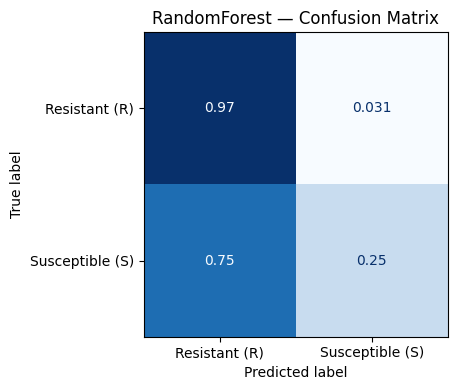

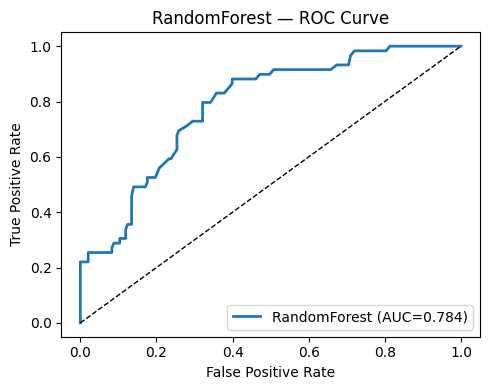

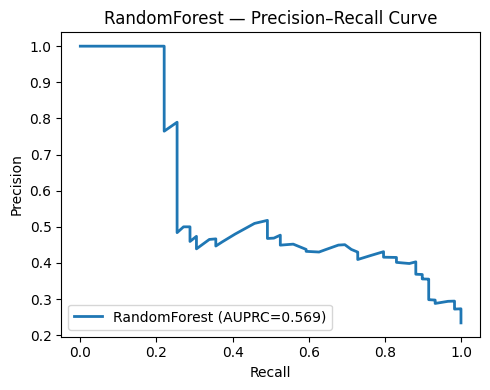

In [351]:


results = {}

for name, pipe in pipes.items():
    results[name], *_ = mm.evaluate_pipeline(
        pipe,
        X_test,
        y_test,
        model_name=name
    )



--- Classification Report: RandomForest ---
                 precision    recall  f1-score   support

  Resistant (R)       1.00      0.22      0.36        59
Susceptible (S)       0.81      1.00      0.89       193

       accuracy                           0.82       252
      macro avg       0.90      0.61      0.63       252
   weighted avg       0.85      0.82      0.77       252


--- Classification Report: LightGBM ---
                 precision    recall  f1-score   support

  Resistant (R)       0.65      0.29      0.40        59
Susceptible (S)       0.81      0.95      0.88       193

       accuracy                           0.80       252
      macro avg       0.73      0.62      0.64       252
   weighted avg       0.78      0.80      0.77       252


--- Classification Report: SVM ---
                 precision    recall  f1-score   support

  Resistant (R)       0.33      0.44      0.37        59
Susceptible (S)       0.81      0.72      0.76       193

       accuracy

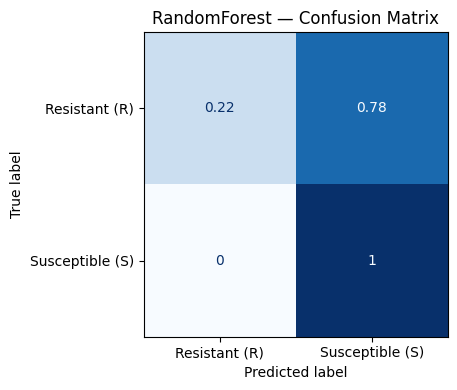

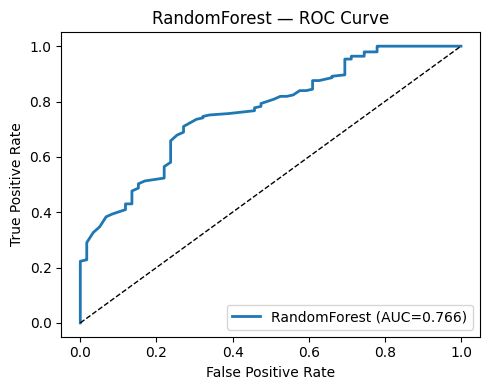

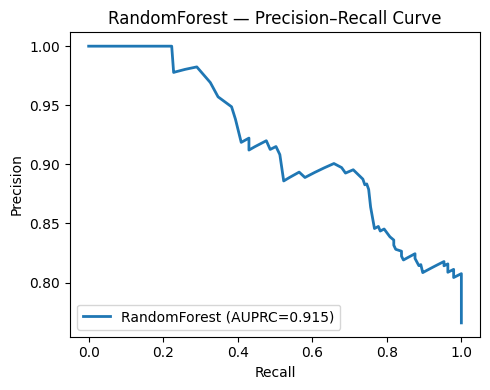

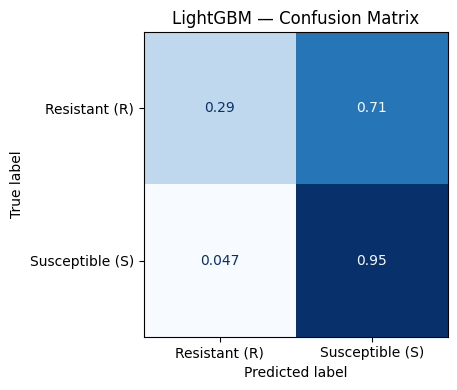

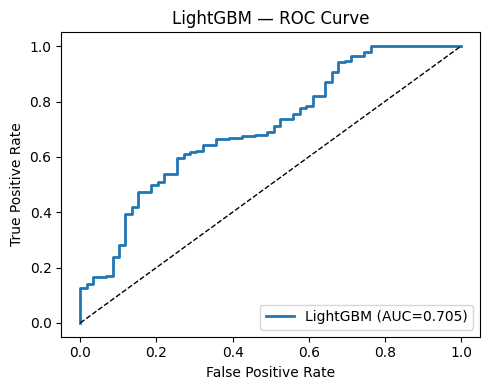

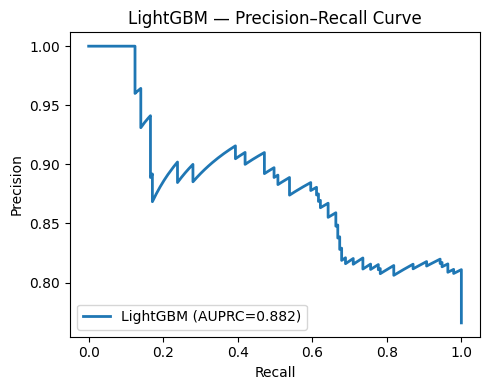

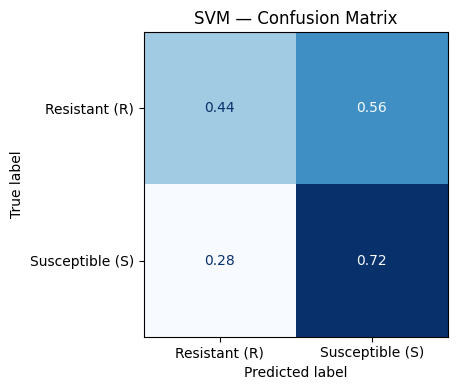

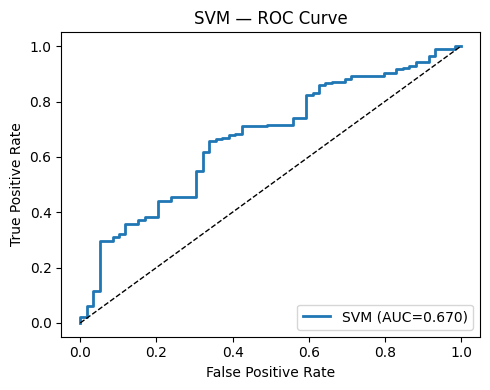

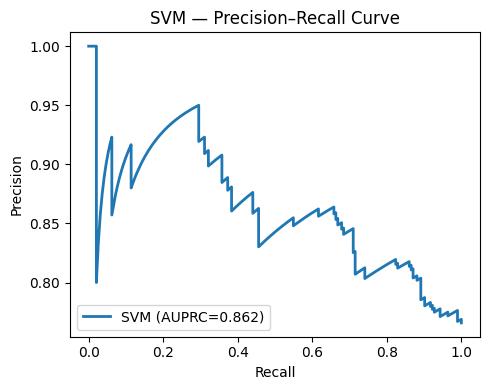

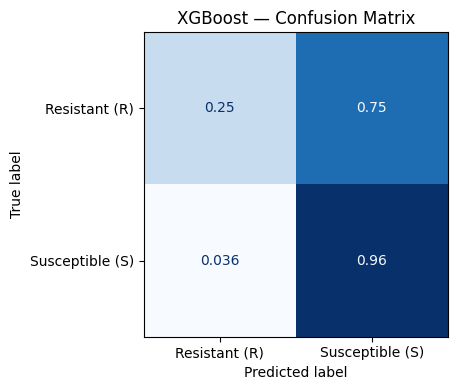

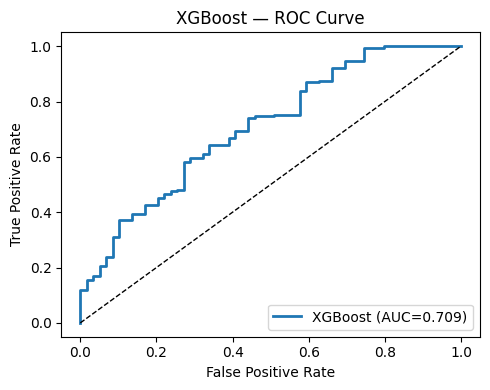

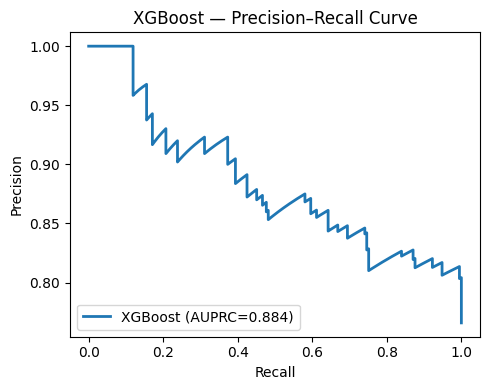

In [102]:


results = {}

for name, pipe in pipes.items():
    results[name], *_ = mm.evaluate_pipeline(
        pipe,
        X_test,
        y_test,
        model_name=name
    )



--- Classification Report: RandomForest ---
                 precision    recall  f1-score   support

  Resistant (R)       1.00      0.22      0.36        59
Susceptible (S)       0.81      1.00      0.89       193

       accuracy                           0.82       252
      macro avg       0.90      0.61      0.63       252
   weighted avg       0.85      0.82      0.77       252


--- Classification Report: LightGBM ---
                 precision    recall  f1-score   support

  Resistant (R)       0.65      0.29      0.40        59
Susceptible (S)       0.81      0.95      0.88       193

       accuracy                           0.80       252
      macro avg       0.73      0.62      0.64       252
   weighted avg       0.78      0.80      0.77       252


--- Classification Report: SVM ---
                 precision    recall  f1-score   support

  Resistant (R)       0.44      0.47      0.46        59
Susceptible (S)       0.84      0.82      0.83       193

       accuracy

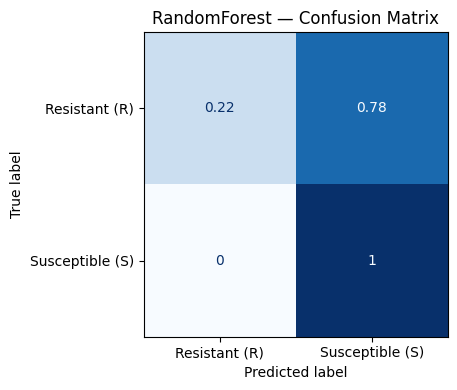

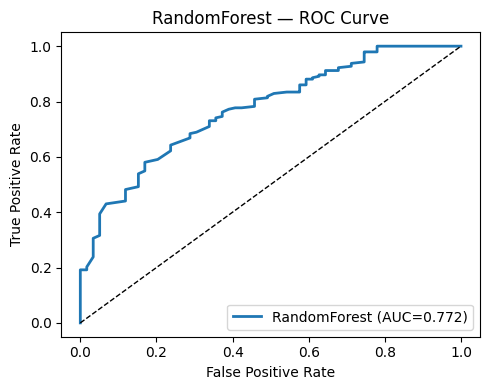

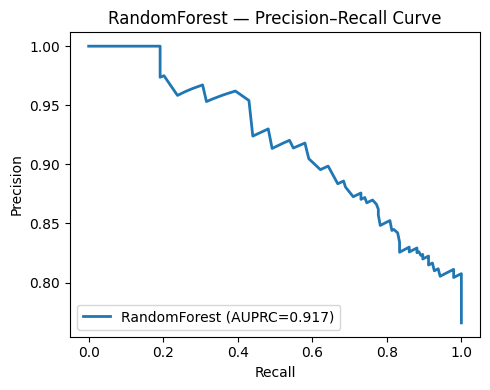

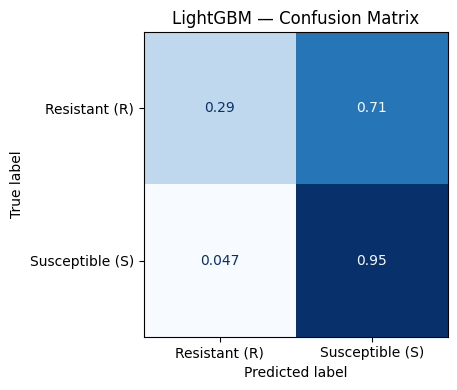

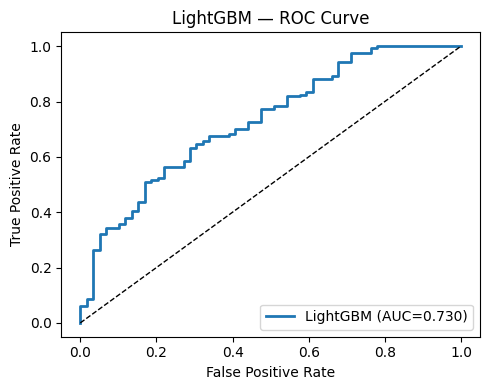

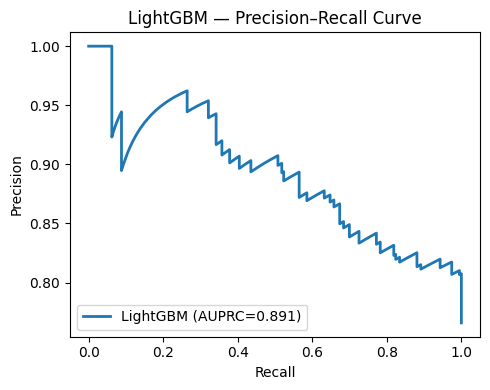

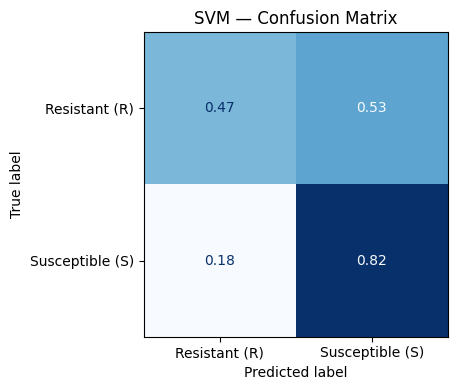

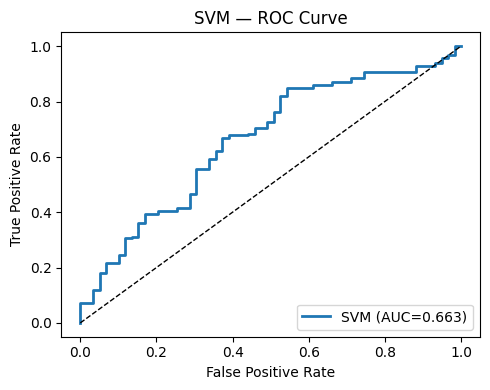

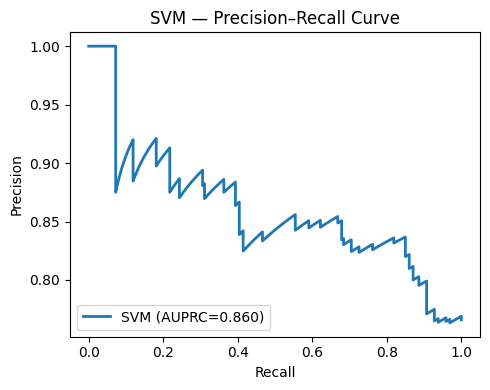

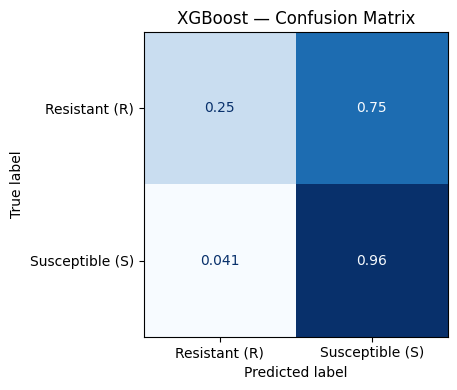

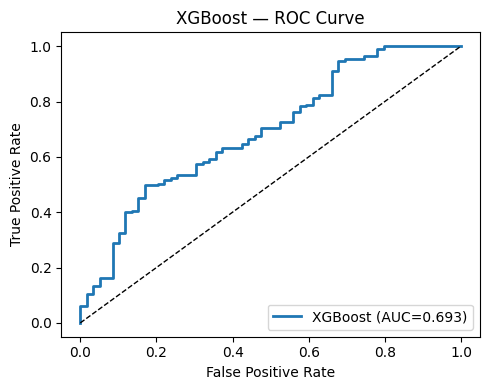

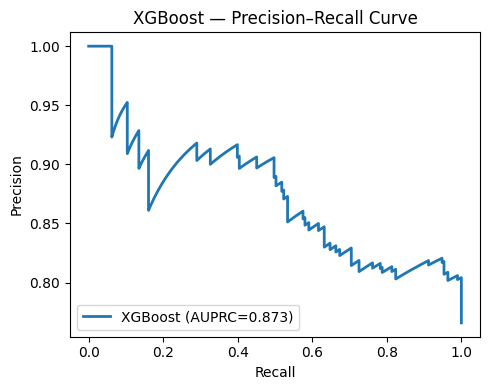

In [84]:


results = {}

for name, pipe in pipes.items():
    results[name], *_ = mm.evaluate_pipeline(
        pipe,
        X_test,
        y_test,
        model_name=name
    )


In [60]:
# !pip install shap

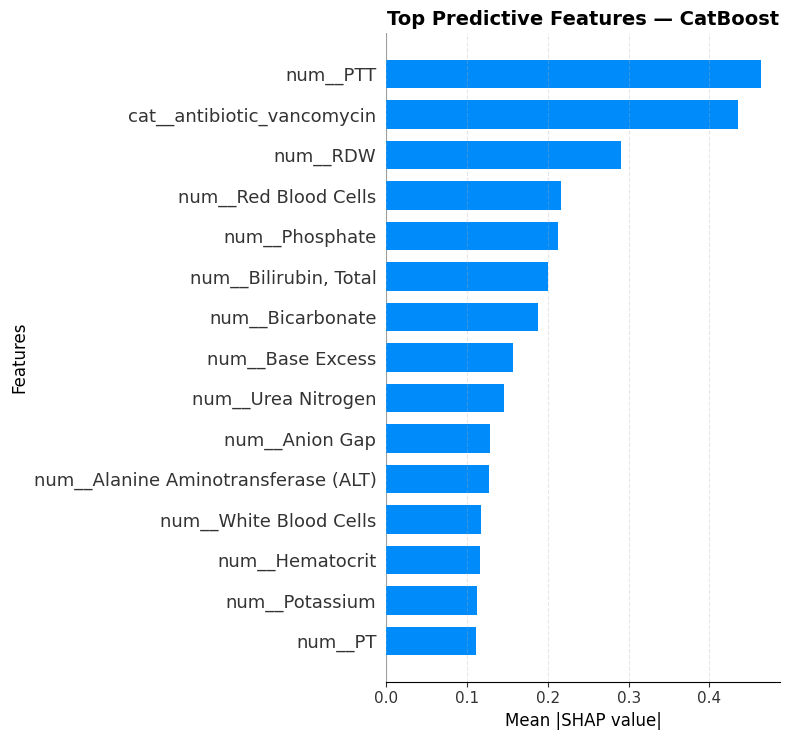

.values =
array([[-0.01257271, -0.0118084 ,  0.        , ...,  0.        ,
         0.0081276 , -0.0251177 ],
       [-0.03094078, -0.03399728,  0.        , ...,  0.        ,
        -0.00843494, -0.0251177 ],
       [ 0.066125  ,  0.17210032,  0.        , ...,  0.        ,
         0.0081276 , -0.01220229],
       ...,
       [-0.02306693, -0.03255045,  0.        , ...,  0.        ,
        -0.00843494,  0.00711037],
       [-0.01257271, -0.00693119,  0.        , ...,  0.        ,
        -0.00937296, -0.02008785],
       [ 0.04938941,  0.07794302,  0.        , ...,  0.        ,
        -0.00843494, -0.02008785]], shape=(252, 180))

.base_values =
array([3.20676239, 3.20676239, 3.20676239, 3.20676239, 3.20676239,
       3.20676239, 3.20676239, 3.20676239, 3.20676239, 3.20676239,
       3.20676239, 3.20676239, 3.20676239, 3.20676239, 3.20676239,
       3.20676239, 3.20676239, 3.20676239, 3.20676239, 3.20676239,
       3.20676239, 3.20676239, 3.20676239, 3.20676239, 3.20676239,
       3

In [95]:
pipe_cb.fit(X_train, y_train)
mm.explain_pipeline(
            pipe_cb,
            X_test,
            model_name="CatBoost"
        )


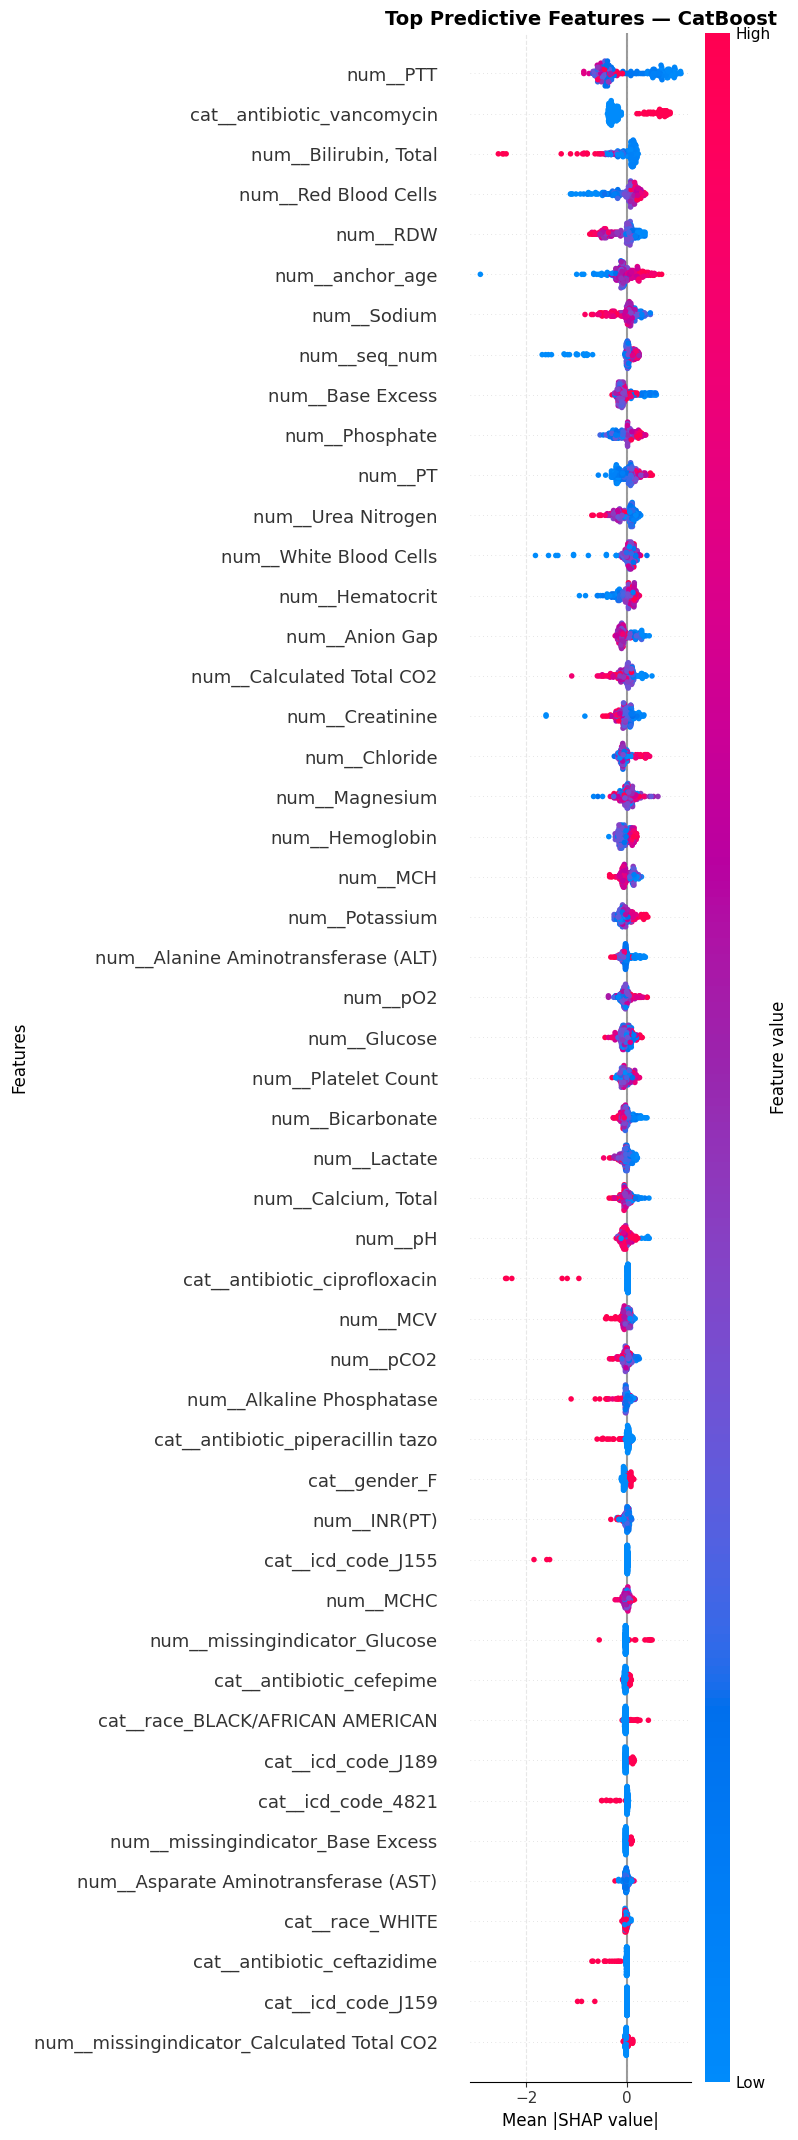

.values =
array([[-0.01978101, -0.00462567,  0.        , ..., -0.00890509,
         0.        , -0.00239656],
       [-0.0551117 , -0.00462567,  0.        , ..., -0.01010182,
         0.        , -0.00711776],
       [ 0.07559587,  0.00648783,  0.        , ..., -0.00663201,
         0.        , -0.00711776],
       ...,
       [-0.06078831, -0.00462567,  0.        , ..., -0.00457239,
         0.        , -0.00711776],
       [-0.01542539, -0.00462567,  0.        , ..., -0.00686844,
         0.        , -0.00239656],
       [ 0.02532492,  0.00648783,  0.        , ..., -0.02670119,
         0.        , -0.00774157]], shape=(252, 156))

.base_values =
array([3.49459216, 3.49459216, 3.49459216, 3.49459216, 3.49459216,
       3.49459216, 3.49459216, 3.49459216, 3.49459216, 3.49459216,
       3.49459216, 3.49459216, 3.49459216, 3.49459216, 3.49459216,
       3.49459216, 3.49459216, 3.49459216, 3.49459216, 3.49459216,
       3.49459216, 3.49459216, 3.49459216, 3.49459216, 3.49459216,
       3

In [104]:
pipe_cb.fit(X_train, y_train)
mm.explain_pipeline(
            pipe_cb,
            X_test,
            model_name="CatBoost",max_display=50
        )


 94%|=================== | 472/504 [00:12<00:00]       

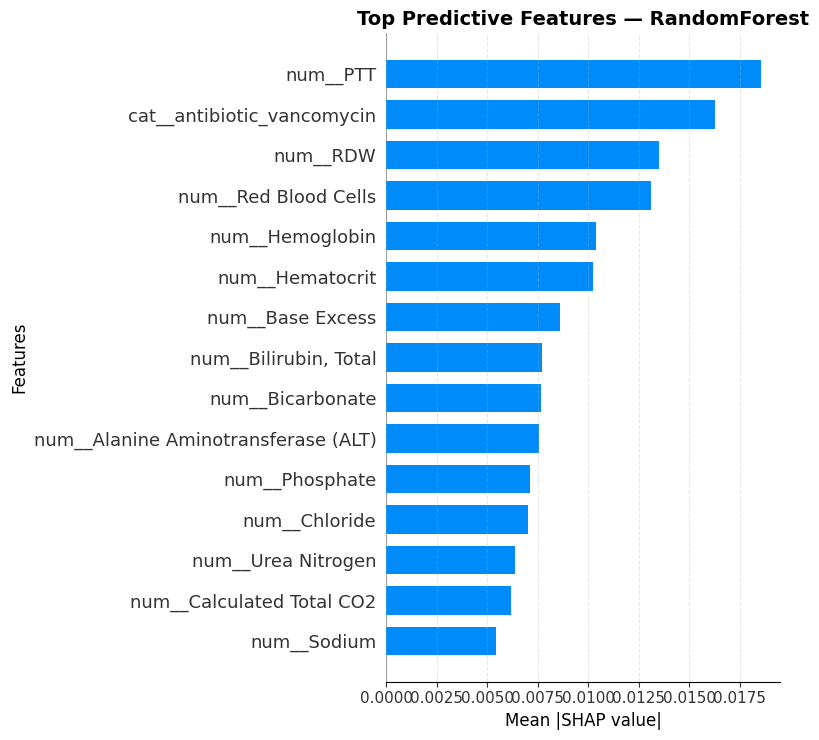

.values =
array([[-9.52341245e-04, -1.28628428e-03,  0.00000000e+00, ...,
        -1.13435185e-03,  3.82275164e-05, -5.39562278e-04],
       [-4.24078048e-03, -3.01305560e-03,  0.00000000e+00, ...,
        -1.82429776e-03, -3.96163972e-05, -1.63436389e-03],
       [ 3.32372895e-03,  3.68265155e-03,  0.00000000e+00, ...,
        -9.44193112e-04,  1.06600533e-04, -8.35992036e-04],
       ...,
       [-1.96226669e-03, -1.37746660e-03,  0.00000000e+00, ...,
        -6.29532216e-04, -2.86904702e-05, -4.32380954e-04],
       [-1.59254092e-03, -1.36872655e-03,  0.00000000e+00, ...,
        -1.56736891e-03, -6.82804206e-05, -7.95185178e-04],
       [ 3.20365558e-03,  2.53382397e-03,  0.00000000e+00, ...,
        -1.37324076e-03, -2.10133480e-04, -1.19646826e-03]],
      shape=(252, 180))

.base_values =
array([0.83293333, 0.83293333, 0.83293333, 0.83293333, 0.83293333,
       0.83293333, 0.83293333, 0.83293333, 0.83293333, 0.83293333,
       0.83293333, 0.83293333, 0.83293333, 0.83293333, 0.83

In [96]:
mm.explain_pipeline(
            pipe_rf,
            X_test,
            model_name="RandomForest"
        )


In [97]:
mm.explain_pipeline(
            pipe_lgb,
            X_test,
            model_name="LightGBM"
        )


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 8.551406, while the model output was 9.264143. If this difference is acceptable you can set check_additivity=False to disable this check.

In [92]:
# !pip install --upgrade shap


In [93]:
mm.explain_pipeline(
            pipe_xgb,
            X_test,
            model_name="XGBoost"
        )


ValueError: could not convert string to float: '[8.3597887E-1]'


--- SHAP for RandomForest ---


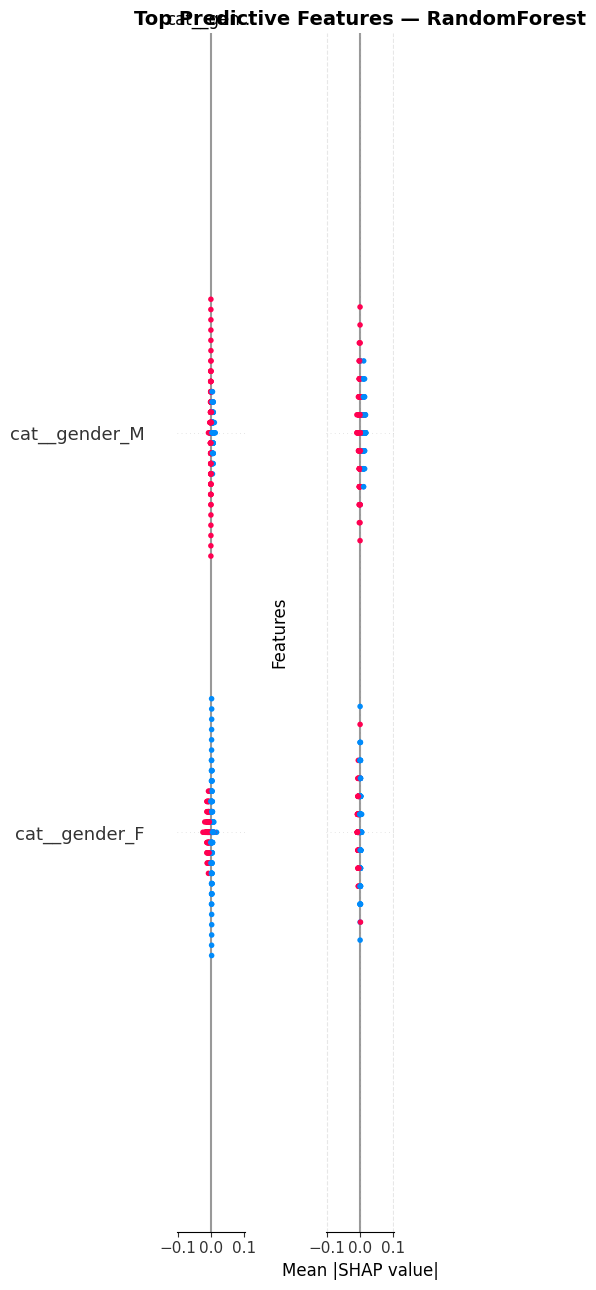


--- SHAP for LightGBM ---


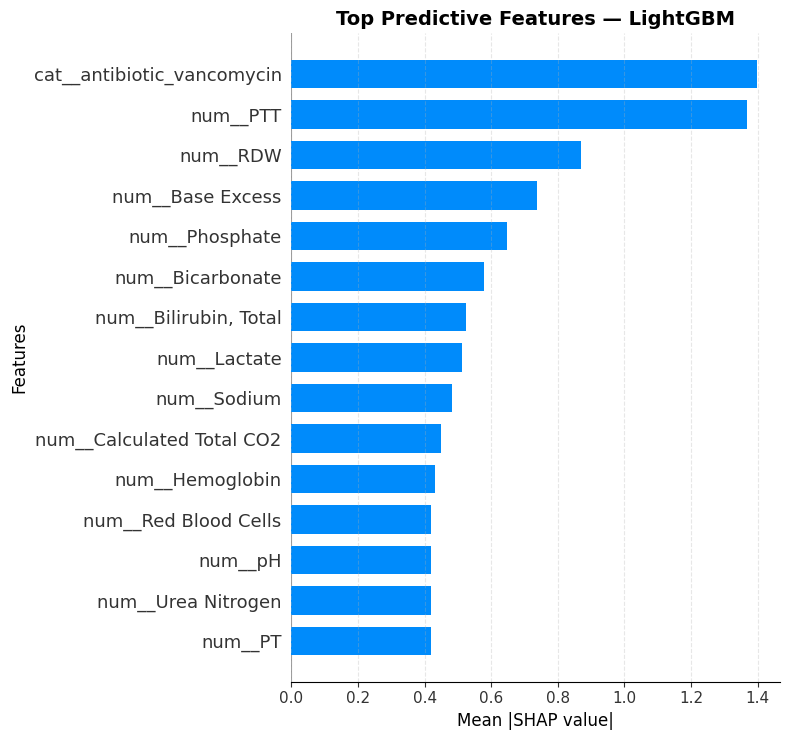


--- SHAP for XGBoost ---


ValueError: could not convert string to float: '[8.3597887E-1]'

In [61]:
for name, pipe in pipes.items():

    if name in ["RandomForest", "LightGBM", "XGBoost", "CatBoost"]:

        print(f"\n--- SHAP for {name} ---")

        mm.explain_pipeline(
            pipe,
            X_test,
            model_name=name
        )
